In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Save objects
import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_excel("../datasets/flood_dataset.xlsx")

df.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [3]:
X = df.drop("flood", axis=1)

y = df["flood"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (115, 10)
Target Shape : (115,)


In [4]:
num_cols = X.columns

num_cols

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub'],
      dtype='str')

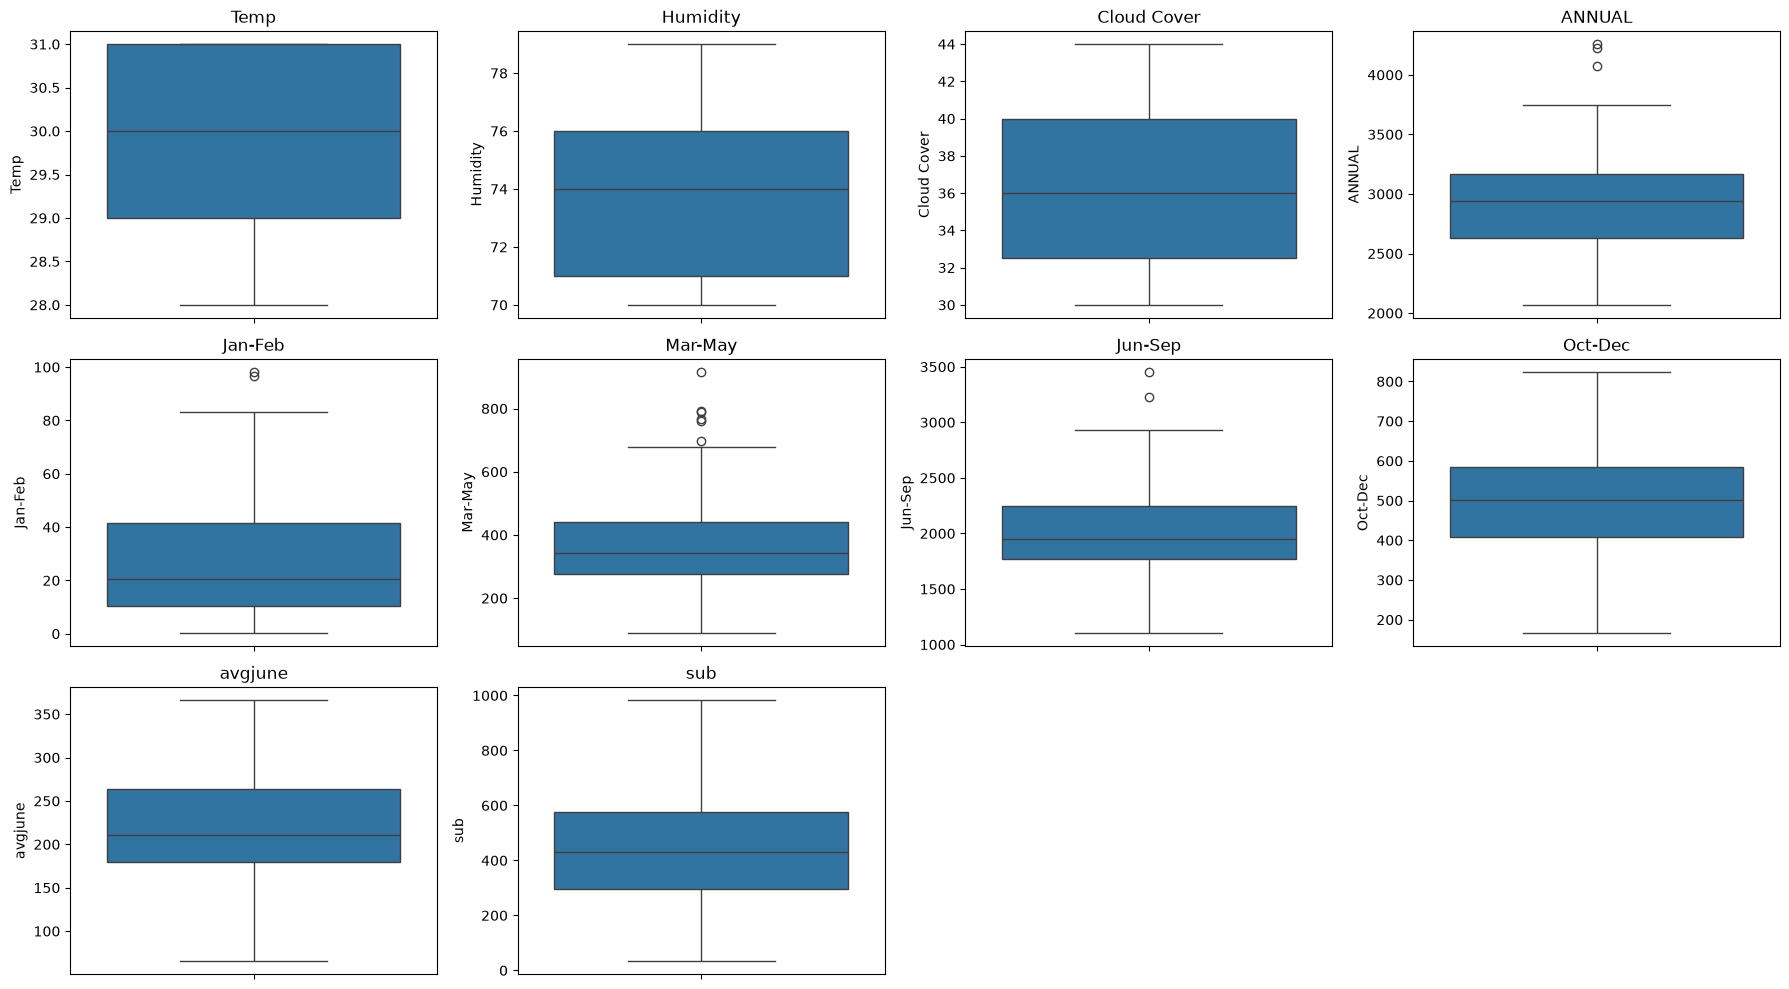

In [5]:
plt.figure(figsize=(18,10))

for i, col in enumerate(num_cols):

    plt.subplot(3,4,i+1)

    sns.boxplot(y=X[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [6]:
X_clean = X.copy()
y_clean = y.copy()

for col in num_cols:

    Q1 = X_clean[col].quantile(0.25)
    Q3 = X_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (X_clean[col] >= lower) & (X_clean[col] <= upper)

    X_clean = X_clean[mask]
    y_clean = y_clean[mask]

In [7]:
print("Original :", df.shape)

print("After Outlier Removal :", X_clean.shape)

Original : (115, 11)
After Outlier Removal : (103, 10)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

In [9]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (82, 10)
Testing Features : (21, 10)
Training Labels : (82,)
Testing Labels : (21,)


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)


In [12]:
X_train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Temp,82.0,-1.293004e-16,1.006154,-1.524530,-0.625167,0.274196,1.173559,1.173559
Humidity,82.0,1.464953e-15,1.006154,-1.347224,-0.906041,0.064563,0.770457,1.829298
Cloud Cover,82.0,-1.334468e-16,1.006154,-1.360609,-1.066385,-0.183711,0.993187,1.934706
ANNUAL,82.0,4.955386e-16,1.006154,-2.035192,-0.655043,-0.059601,0.652888,2.298396
Jan-Feb,82.0,2.961723e-17,1.006154,-1.248292,-0.853085,-0.170453,0.689501,2.590207
Mar-May,82.0,-3.357748e-16,1.006154,-2.252018,-0.820616,-0.056744,0.465121,2.688152
Jun-Sep,82.0,5.364103e-16,1.006154,-2.039457,-0.683223,-0.163124,0.574079,2.662329
Oct-Dec,82.0,5.686508e-16,1.006154,-2.714274,-0.664865,0.100587,0.793679,2.121178
avgjune,82.0,5.354795e-16,1.006154,-2.462473,-0.584858,-0.071223,0.795861,2.142556
sub,82.0,-1.374239e-16,1.006154,-2.319723,-0.593832,0.006799,0.640866,2.456321


In [13]:
import os

os.makedirs("../models", exist_ok=True)

In [14]:
joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [15]:
X_train_scaled.to_csv("../datasets/X_train.csv", index=False)

X_test_scaled.to_csv("../datasets/X_test.csv", index=False)

y_train.to_csv("../datasets/y_train.csv", index=False)

y_test.to_csv("../datasets/y_test.csv", index=False)

print("Processed Data Saved")

Processed Data Saved


In [16]:
print("="*50)
print("PREPROCESSING SUMMARY")
print("="*50)

print("Original Dataset :", df.shape)
print("Processed Dataset :", X_clean.shape)

print("\nTraining Set :", X_train.shape)
print("Testing Set :", X_test.shape)

print("\nScaling Applied : Yes")
print("Scaler Saved : models/scaler.pkl")

PREPROCESSING SUMMARY
Original Dataset : (115, 11)
Processed Dataset : (103, 10)

Training Set : (82, 10)
Testing Set : (21, 10)

Scaling Applied : Yes
Scaler Saved : models/scaler.pkl
